In [1]:
import os
import zipfile
from pathlib import Path
import sys


# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from src.utils import get_transforms
from src.train import train_model
from src.models import RadriografiaEfficientNetB2
import torch.nn as nn
import torch

# Semilla para reproducibilidad
random.seed(50)

import yaml

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [3]:
# Parameters
batch_size = config["model"]["parameters"]["batch_size"]
learning_rate = config["model"]["parameters"]["learning_rate"]
epochs = config["model"]["parameters"]["epochs"]
num_classes = config["model"]["parameters"]["num_classes"]

# Paths
save_best_model_path = PROJECT_ROOT / config["model"]["paths"]["save_model_path"]
save_historial_path = PROJECT_ROOT / config["model"]["paths"]["save_historial_path"]

In [4]:
input_shape = config["model"]["transforms"]["input_shape"]
mean = config["model"]["transforms"]["mean"]
std = config["model"]["transforms"]["std"]

transforms_model = get_transforms(output_size=[input_shape[0], input_shape[1]], mean=mean,
                                   std=std, output_channels=input_shape[2])

train_path =  PROJECT_ROOT / config["model"]["paths"]["train_path"]
test_path = PROJECT_ROOT / config["model"]["paths"]["test_path"]

dataset_train = ImageFolder(root=train_path, transform=transforms_model)
dataset_test = ImageFolder(root=test_path, transform=transforms_model)

loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [5]:
model = RadriografiaEfficientNetB2(num_classes=num_classes, freeze_backbone=True)

criterion = nn.CrossEntropyLoss()
parameters_to_optimize = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(parameters_to_optimize, lr=learning_rate)

history = train_model(model=model, train_loader=loader_train, val_loader=loader_test,
                    criterion=criterion, optimizer=optimizer, num_epochs=epochs,
                    save_best_model_path=save_best_model_path, save_historial_path=save_historial_path)

Época [1/10] | Train Loss: 2.0616 Acc: 0.1778 | Val Loss: 2.0621 Acc: 0.1458 **
Modelo guardado en: /home/alexc0dex/Escritorio/UPC/procesamientoImagenes/TF/bone-fracture-classification/checkpoints/radriografia_efficientnet_b2.h5
Época [2/10] | Train Loss: 2.0303 Acc: 0.2278 | Val Loss: 2.0569 Acc: 0.1667 **
Modelo guardado en: /home/alexc0dex/Escritorio/UPC/procesamientoImagenes/TF/bone-fracture-classification/checkpoints/radriografia_efficientnet_b2.h5
Época [3/10] | Train Loss: 2.0085 Acc: 0.2449 | Val Loss: 2.0547 Acc: 0.1667 
Época [4/10] | Train Loss: 1.9963 Acc: 0.2902 | Val Loss: 2.0448 Acc: 0.1771 **
Modelo guardado en: /home/alexc0dex/Escritorio/UPC/procesamientoImagenes/TF/bone-fracture-classification/checkpoints/radriografia_efficientnet_b2.h5
Época [5/10] | Train Loss: 1.9779 Acc: 0.3307 | Val Loss: 2.0379 Acc: 0.2396 **
Modelo guardado en: /home/alexc0dex/Escritorio/UPC/procesamientoImagenes/TF/bone-fracture-classification/checkpoints/radriografia_efficientnet_b2.h5
Época 

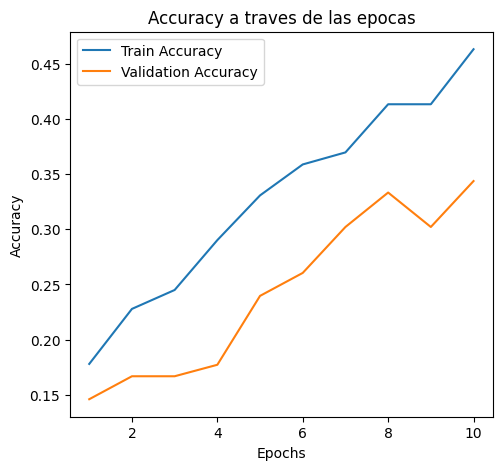

In [8]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy a traves de las epocas')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

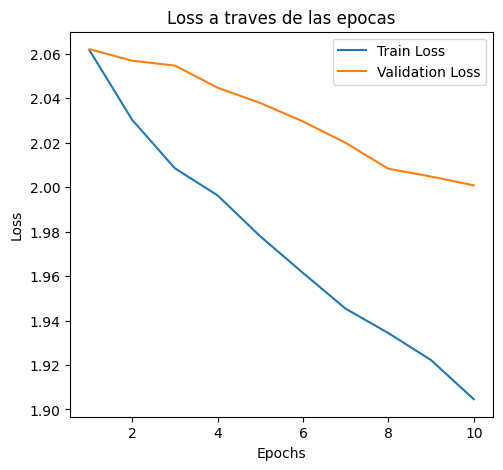

In [9]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Loss a traves de las epocas')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()